Setup env

In [ ]:
pip install nltk gensim scikit-learn numpy

In [ ]:
pip install --user --upgrade scipy

In [ ]:
import nltk

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

Data Exploration

In [19]:
def load_tweet_file(path):
    with open(path, 'r', encoding='utf-8', errors='replace') as f:
        content = f.read()
    if '\n' in content.strip() and content.count('\n') > 5:
        tweets = [line.strip() for line in content.split('\n') if line.strip()]
    else:
        tweets = [t.strip() for t in content.split(',') if t.strip()]
    return pd.DataFrame({'text': tweets})

neg = load_tweet_file('../data/processedNegative.csv')
pos = load_tweet_file('../data/processedPositive.csv')
neu = load_tweet_file('../data/processedNeutral.csv')

print(neg.shape, pos.shape, neu.shape)


(1116, 1) (1183, 1) (1566, 1)


(3865, 2)
label
Neutral     1566
Positive    1183
Negative    1116
Name: count, dtype: int64


<Axes: xlabel='label'>

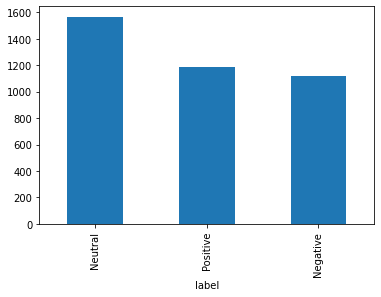

In [23]:
neg['label'] = 'Negative'
pos['label'] = 'Positive'
neu['label'] = 'Neutral'

df = pd.concat([neg, pos, neu], ignore_index=True)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print(df.shape)
print(df['label'].value_counts())

df.head()

df['label'].value_counts().plot(kind='bar')